# Surrogate Factory — UCFatigue
## Chapter 9. Model Validation
Objectives:
- **9.0** Validate the train/test split quality (voxel tesselation proximity method).
- **9.1** Predict fatigue loads on the test set.
- **9.2** Compute metrics (R², MAE, quantile90).
- **9.2b** KS distribution tests: train vs test residuals.
- **9.3** Validate against requirements defined in SF_1.
- **9.4** Generate scatter and ratio plots.

### 0. Workflow initialisation

In [1]:
import sys
from pathlib import Path

# add repo root so validationlib is importable
repo_root = str(Path('..').resolve().parent)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from IPython.display import display, HTML, JSON
from surrogate_factory.workflow import Workflow

workflow = Workflow('pipeline_config.yaml')
workflow.resume()

2026-06-25 12:24:42 - SurrogateFactoryLogs - INFO - Initializing Workflow...


2026-06-25 12:24:42 - SurrogateFactoryLogs - INFO - Setting up Workflow folders and paths...


2026-06-25 12:24:42 - SurrogateFactoryLogs - INFO - Changing working directory to Data folder: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data


2026-06-25 12:24:42 - SurrogateFactoryLogs - INFO - Loading default metadata schema...


2026-06-25 12:24:42 - SurrogateFactoryLogs - INFO - Tracker requested: 'mlflow'


...

Setting tracking uri: file:///Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/mlruns
2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Adding methods to Catalog from configuration.


2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Workflow initialization completed successfully.


2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Resuming workflow job: 'UCFATIGUE_1'


2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Workflow data loaded successfully.


2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Workflow metadata successfully loaded for resume.


### 9. Model Validation

In [2]:
workflow.import_metadata(stage_name='SF_9_Model_Validation')

2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Importing metadata for stage: 'SF_9_Model_Validation'


2026-06-25 12:24:43 - SurrogateFactoryLogs - INFO - Updating metadata for stage 'Model_Validation' in memory.


In [3]:
Train_set = workflow.load_data(workflow.config['job_name'] + '_Train_set.csv')
Val_set   = workflow.load_data(workflow.config['job_name'] + '_Val_set.csv')
Test_set  = workflow.load_data(workflow.config['job_name'] + '_Test_set.csv')
print(f'Train set : {Train_set.shape}')
print(f'Val set   : {Val_set.shape}')
print(f'Test set  : {Test_set.shape}')

2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Train_set.csv' (Format: csv)


2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (703, 29)


2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Val_set.csv' (Format: csv)


2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (87, 29)


2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/UCFATIGUE_1_Test_set.csv' (Format: csv)


2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (79, 29)


Train set : (703, 29)
Val set   : (87, 29)
Test set  : (79, 29)


#### 9.0 Split Validation
Checks that the train/test split is statistically sound:
- **Residual voxel proportion**: fraction of test points in category combinations not seen in training (target ≤ 0.05).
- **Phacking**: test points too close to training points (data leakage risk).
- **Isolated test**: test points too far from any training point (extrapolation).
- **Chi² p-value**: distribution of train vs test samples per voxel (target ≥ 0.05).

In [4]:
from model_validation.split_val import split_validation
split_result = split_validation(workflow, Train_set, Test_set)

2026-06-25 12:24:44 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'split_validation'



  Metric                       Value    Status  (threshold)
  ----------------------------------------------------------
  Residual voxel proportion  :  0.000   ✓   (≤ 0.05)
  Valid test proportion      :  0.962
  Phacking test proportion   :  0.025
  Isolated test proportion   :  0.013
  Isolated train proportion  :  0.006
  Chi² p-value               : 0.0011   ✗   (≥ 0.05)


#### 9.0b Data Coverage — Train / Val / Test
Distribution of **inputs** and **outputs** across the three sets using validationlib.
- **doubleHistogram**: overlaid histograms for density comparison.
- **PCA scatter**: 2-D projection of 8-D input space coloured by set membership.

Numeric inputs used for plots: ['FLAP', 'Altitude', 'TAS', 'Mass', 'q', 'gamma', 'Xcg(%CMA)']


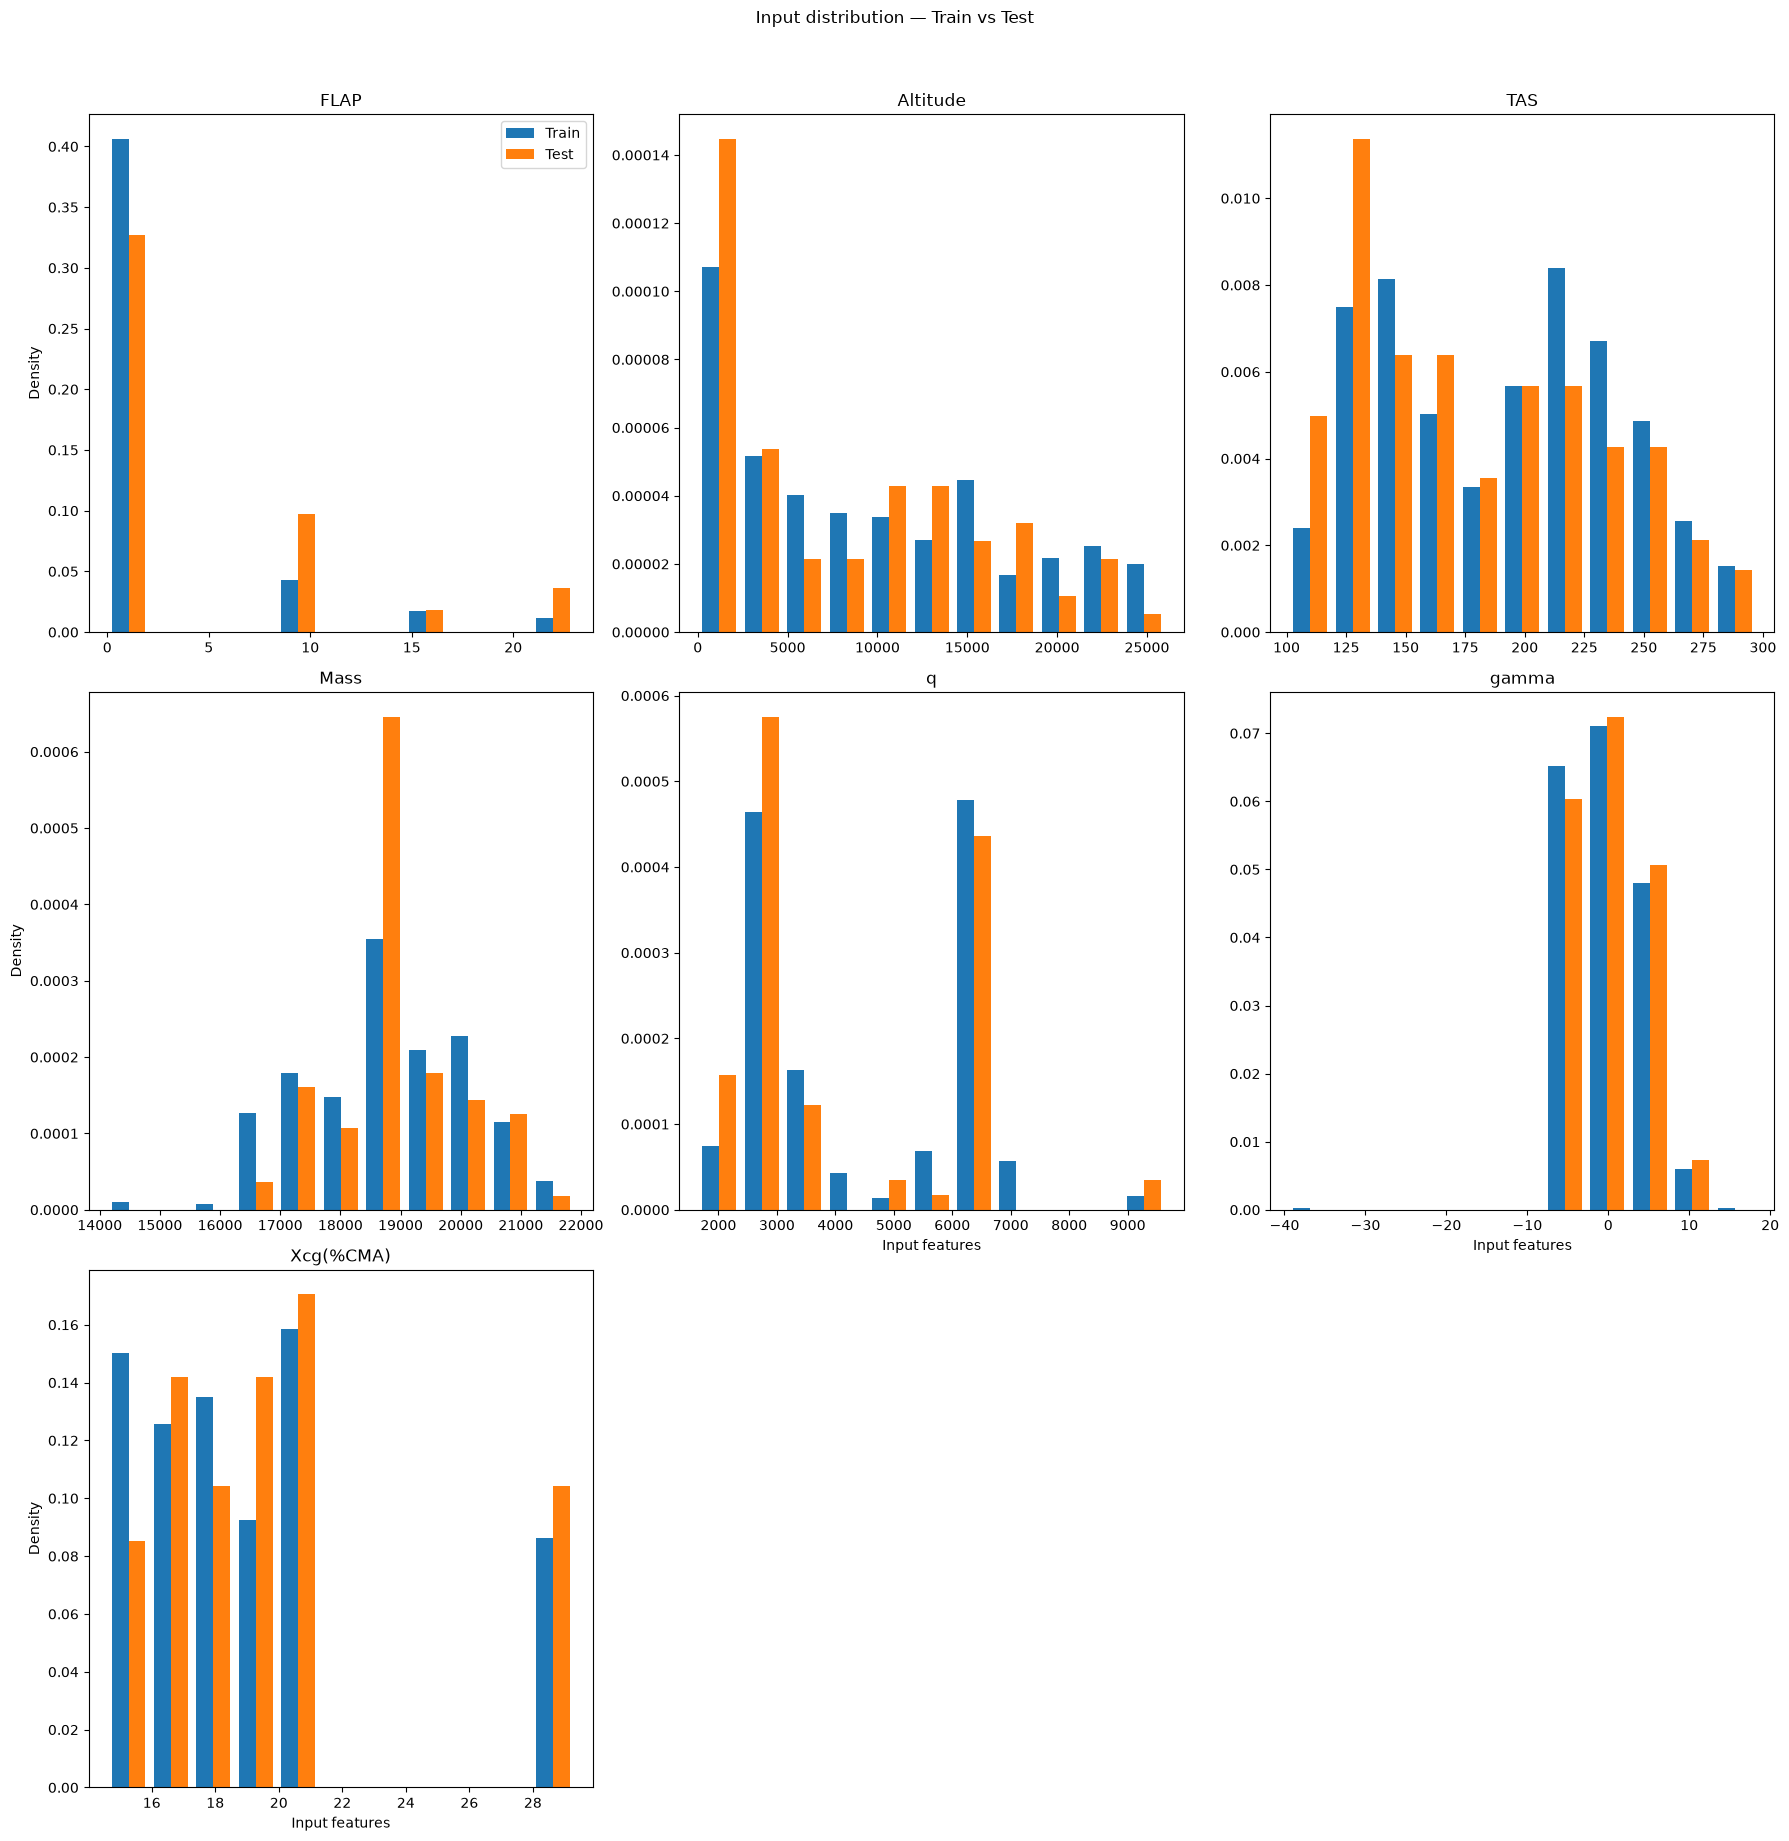

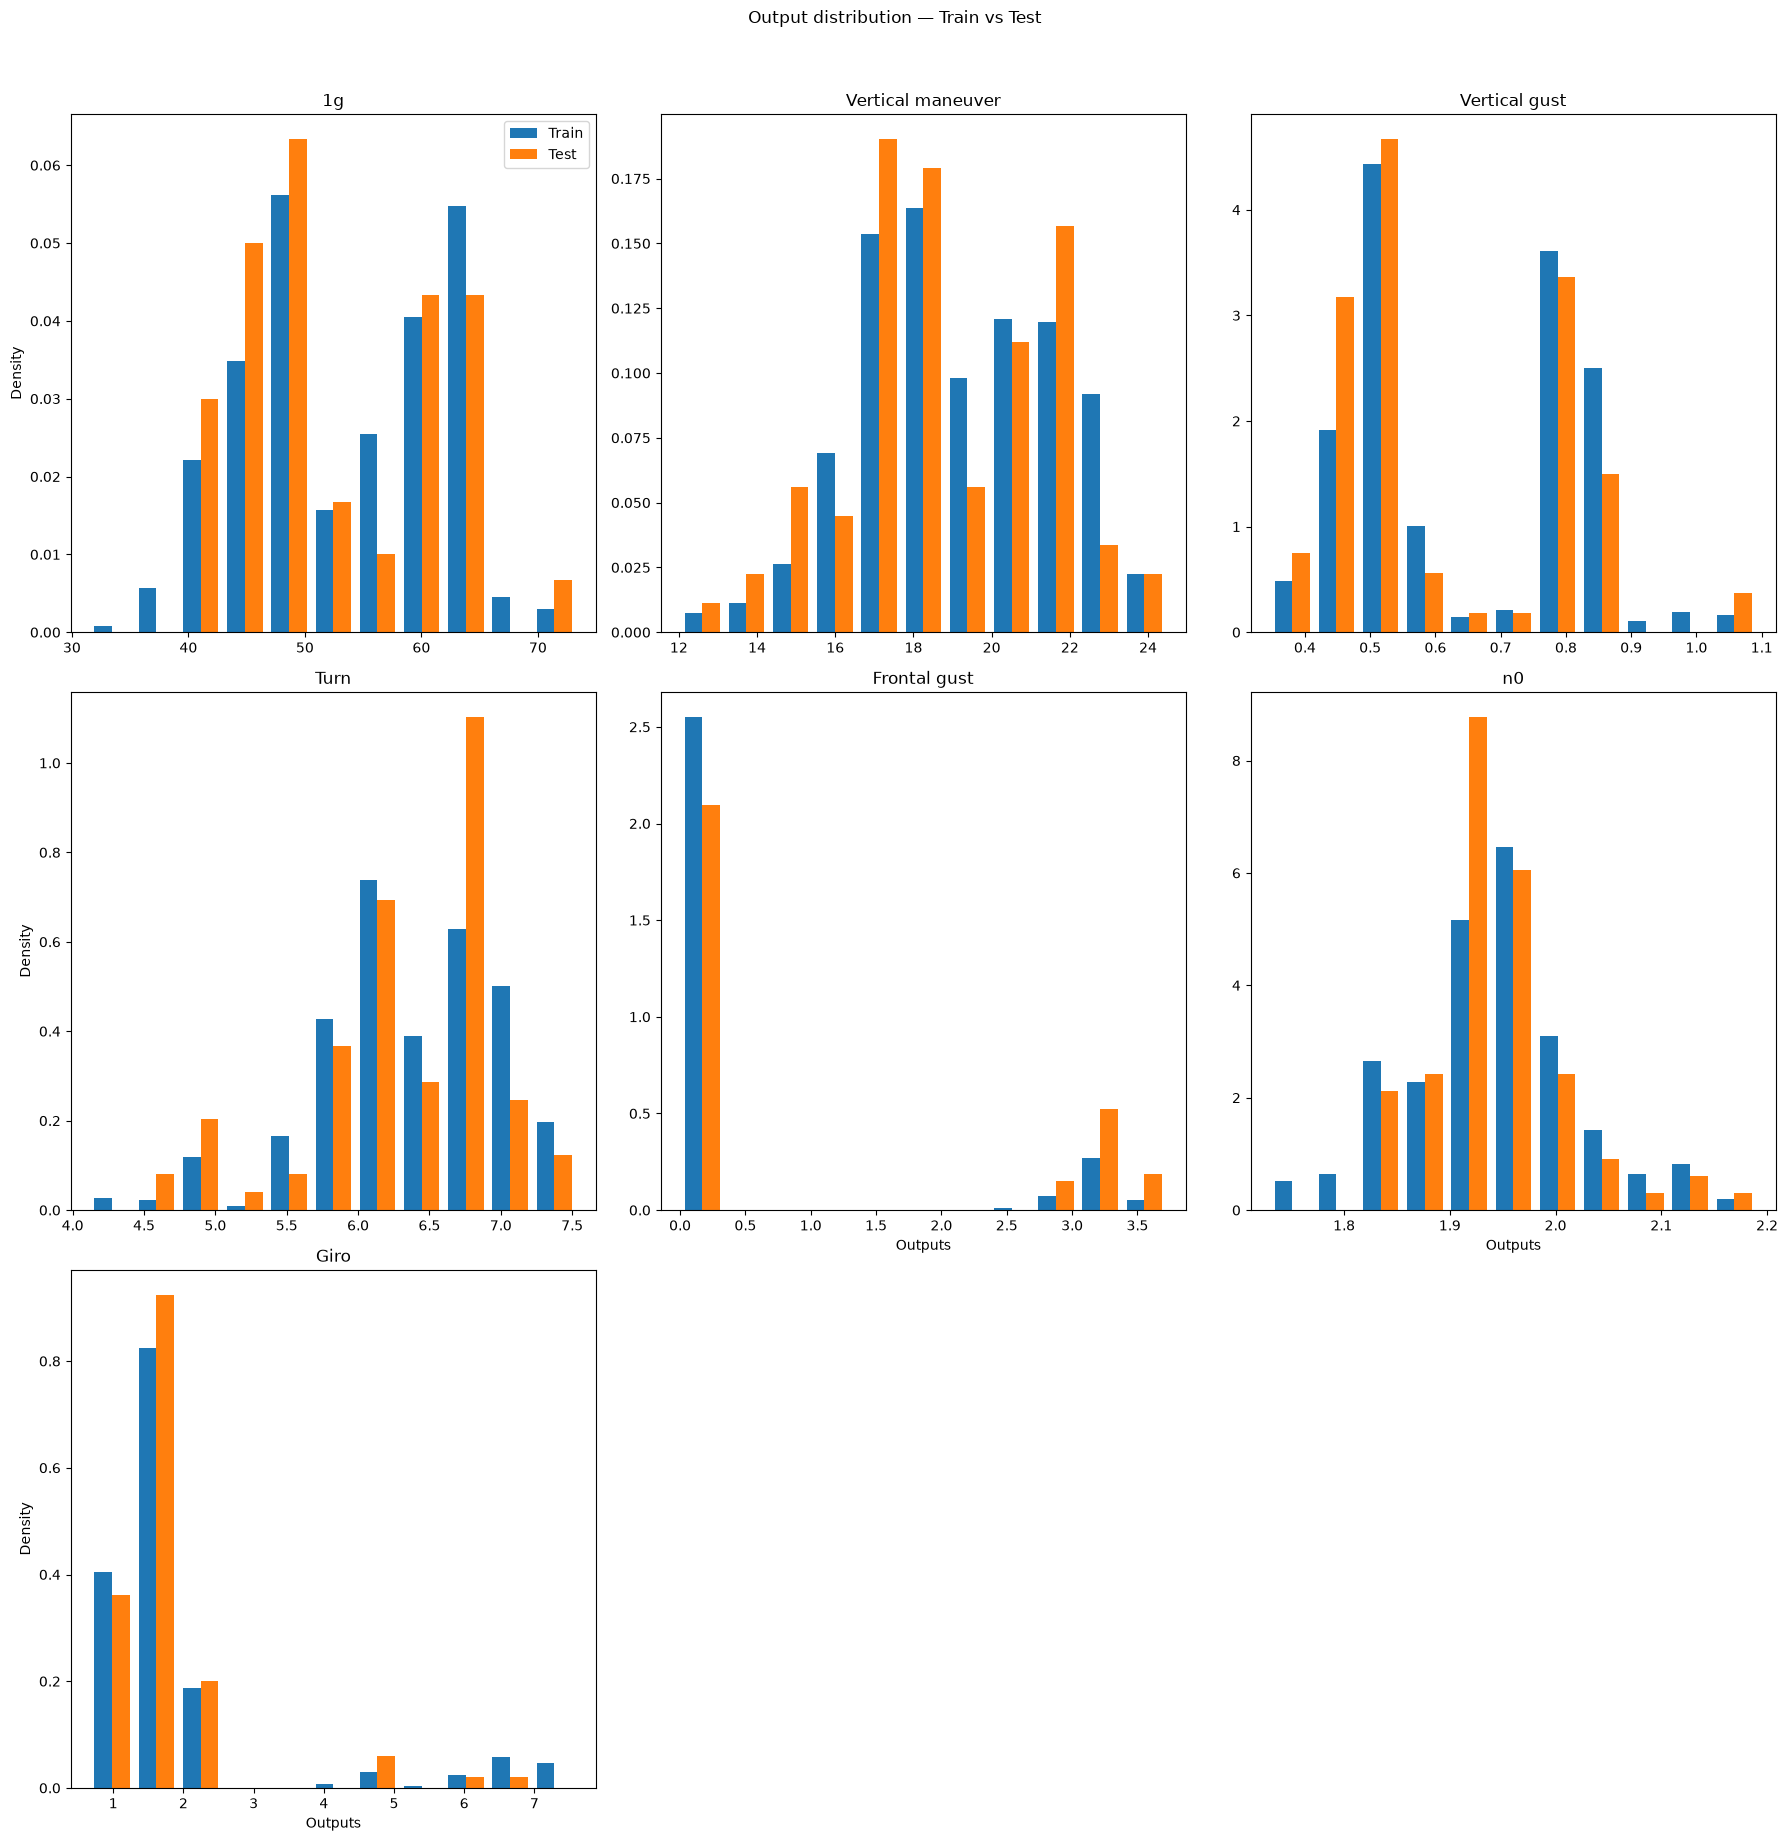

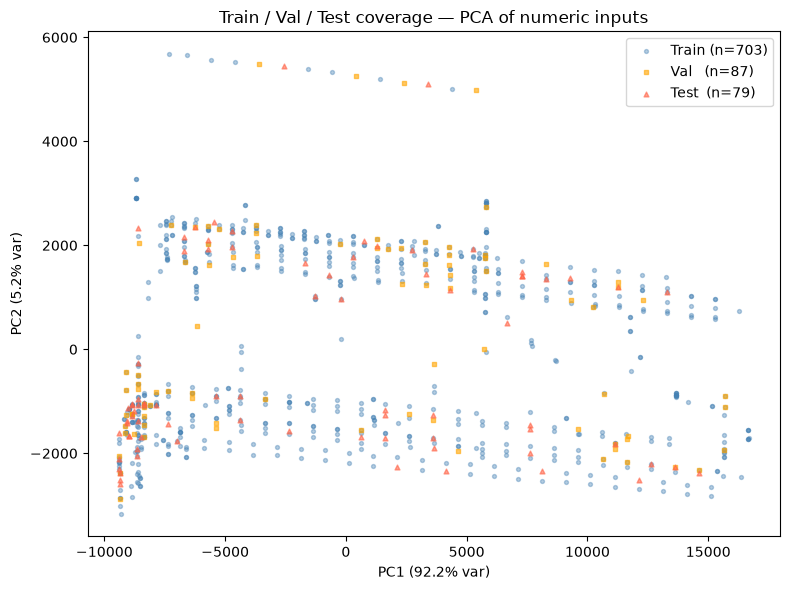

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from validationlib.plots.hist import doubleHistogram
from validationlib.plots.cumu import doublecumulative

ms = workflow.metadata.get_step_data(['metadata', 'Model_Selection'])
inputs  = ms['inputs']
outputs = ms['outputs']

# Exclude categorical columns (strings) — PCA and histograms need numeric data
num_inputs = Train_set[inputs].select_dtypes(include='number').columns.tolist()
print(f'Numeric inputs used for plots: {num_inputs}')

# — Input distribution: Train vs Test (numeric only) —
fig = doubleHistogram(
    Train_set[num_inputs], Test_set[num_inputs],
    x1label='Train', x2label='Test', xlabel='Input features',
    multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
)
fig.suptitle('Input distribution — Train vs Test', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

# — Output distribution: Train vs Test —
fig2 = doubleHistogram(
    Train_set[outputs], Test_set[outputs],
    x1label='Train', x2label='Test', xlabel='Outputs',
    multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
)
fig2.suptitle('Output distribution — Train vs Test', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig2)

# — PCA scatter: 3 sets in 2-D input space (numeric inputs only) —
all_num = pd.concat([Train_set[num_inputs], Val_set[num_inputs], Test_set[num_inputs]], axis=0)
pca = PCA(n_components=2)
pca.fit(all_num)
trPC = pca.transform(Train_set[num_inputs])
vlPC = pca.transform(Val_set[num_inputs])
tsPC = pca.transform(Test_set[num_inputs])

fig3, ax = plt.subplots(figsize=(8, 6))
ax.scatter(trPC[:,0], trPC[:,1], s=8,  alpha=0.4, label=f'Train (n={len(Train_set)})',  color='steelblue')
ax.scatter(vlPC[:,0], vlPC[:,1], s=12, alpha=0.6, label=f'Val   (n={len(Val_set)})',    color='orange',    marker='s')
ax.scatter(tsPC[:,0], tsPC[:,1], s=12, alpha=0.6, label=f'Test  (n={len(Test_set)})',   color='tomato',    marker='^')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(f'Train / Val / Test coverage — PCA of numeric inputs')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig3)

#### 9.1 Predictions

In [6]:
from model_validation.prediction import predict
model_output = predict(workflow, Test_set)
train_output = predict(workflow, Train_set)  # needed for distribution tests
model_output.head()

2026-06-25 12:24:45 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


2026-06-25 12:24:45 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


,MLP__1g,MLP__Vertical maneuver,MLP__Vertical gust,MLP__Turn,MLP__Frontal gust,MLP__n0,MLP__Giro,GradientBoosting__1g,GradientBoosting__Vertical maneuver,GradientBoosting__Vertical gust,GradientBoosting__Turn,GradientBoosting__Frontal gust,GradientBoosting__n0,GradientBoosting__Giro
0,48.116354,18.301333,0.512590,6.665048,0.066196,1.996795,2.343866,50.365509,18.517471,0.544685,6.776805,0.000250,1.975122,1.414922
1,49.274637,17.432735,0.481723,5.964015,3.254898,2.008440,1.704700,46.939503,17.199274,0.510088,5.840741,3.161449,1.911323,1.434768
2,62.542374,22.264333,0.785046,7.165291,0.160726,1.979085,1.806120,62.113586,22.274098,0.801744,7.116474,0.000261,1.947933,1.708156
3,38.457692,13.294009,0.314032,4.501867,3.214161,1.898213,2.197788,39.614434,13.928571,0.375542,4.680852,3.273822,1.954422,0.687145
4,72.892503,24.389639,1.117207,7.442066,-0.012308,2.087431,1.786331,73.311484,24.357148,1.068684,7.438323,0.000261,1.863998,1.998753


#### 9.2 Metrics

In [7]:
from model_validation.score import calculate_metrics
metrics = calculate_metrics(workflow, Test_set, model_output)
JSON(metrics)

2026-06-25 12:24:45 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'calculate_metrics'



Output                              R² MLPR² GradientBoosting
--------------------------------------------------------
1g                                  0.9872        0.9936
Vertical maneuver                   0.9701        0.9854
Vertical gust                       0.9257        0.9966
Turn                                0.9501        0.9674
Frontal gust                        0.9915        0.9991
n0                                 -0.5005        0.9477
Giro                                0.0449        0.8595

Best model per output (by R²):
  1g                           → GradientBoosting  (R²=0.9936)
  Vertical maneuver            → GradientBoosting  (R²=0.9854)
  Vertical gust                → GradientBoosting  (R²=0.9966)
  Turn                         → GradientBoosting  (R²=0.9674)
  Frontal gust                 → GradientBoosting  (R²=0.9991)
  n0                           → GradientBoosting  (R²=0.9477)
  Giro                         → GradientBoosting  (R²=0.8595)


<IPython.core.display.JSON object>

#### 9.2b Distribution Tests (KS: train vs test residuals)
Kolmogorov-Smirnov test comparing the residual distributions on the **training set** vs the **test set** for each model and output.
- H₀: both distributions are the same.
- p-value ≥ 0.05 → ✓ no significant difference (healthy generalisation).
- p-value < 0.05 → ✗ residuals differ (possible overfitting or distribution shift).

In [8]:
from model_validation.score import distribution_tests
ks_results = distribution_tests(workflow, Train_set, Test_set, train_output, model_output)

2026-06-25 12:24:45 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'distribution_tests'



  KS test p-values — MLP  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  1g                                0.7559           ✓
  Vertical maneuver                 0.7222           ✓
  Vertical gust                     0.9982           ✓
  Turn                              0.2807           ✓
  Frontal gust                      0.4288           ✓
  n0                                0.9312           ✓
  Giro                              0.3186           ✓

  KS test p-values — GradientBoosting  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  1g                                0.8997           ✓
  Vertical maneuver                 0.4567           ✓
  Vertical gust                     0.6392           ✓
  Turn                              0.3363           ✓
  Frontal 

#### 9.2c Residual Distribution Plots
Visual comparison of **train vs test residuals** per output:
- `doubleHistogram`: density overlap.
- `doublecumulative`: CDF overlap — large gap → distribution shift.

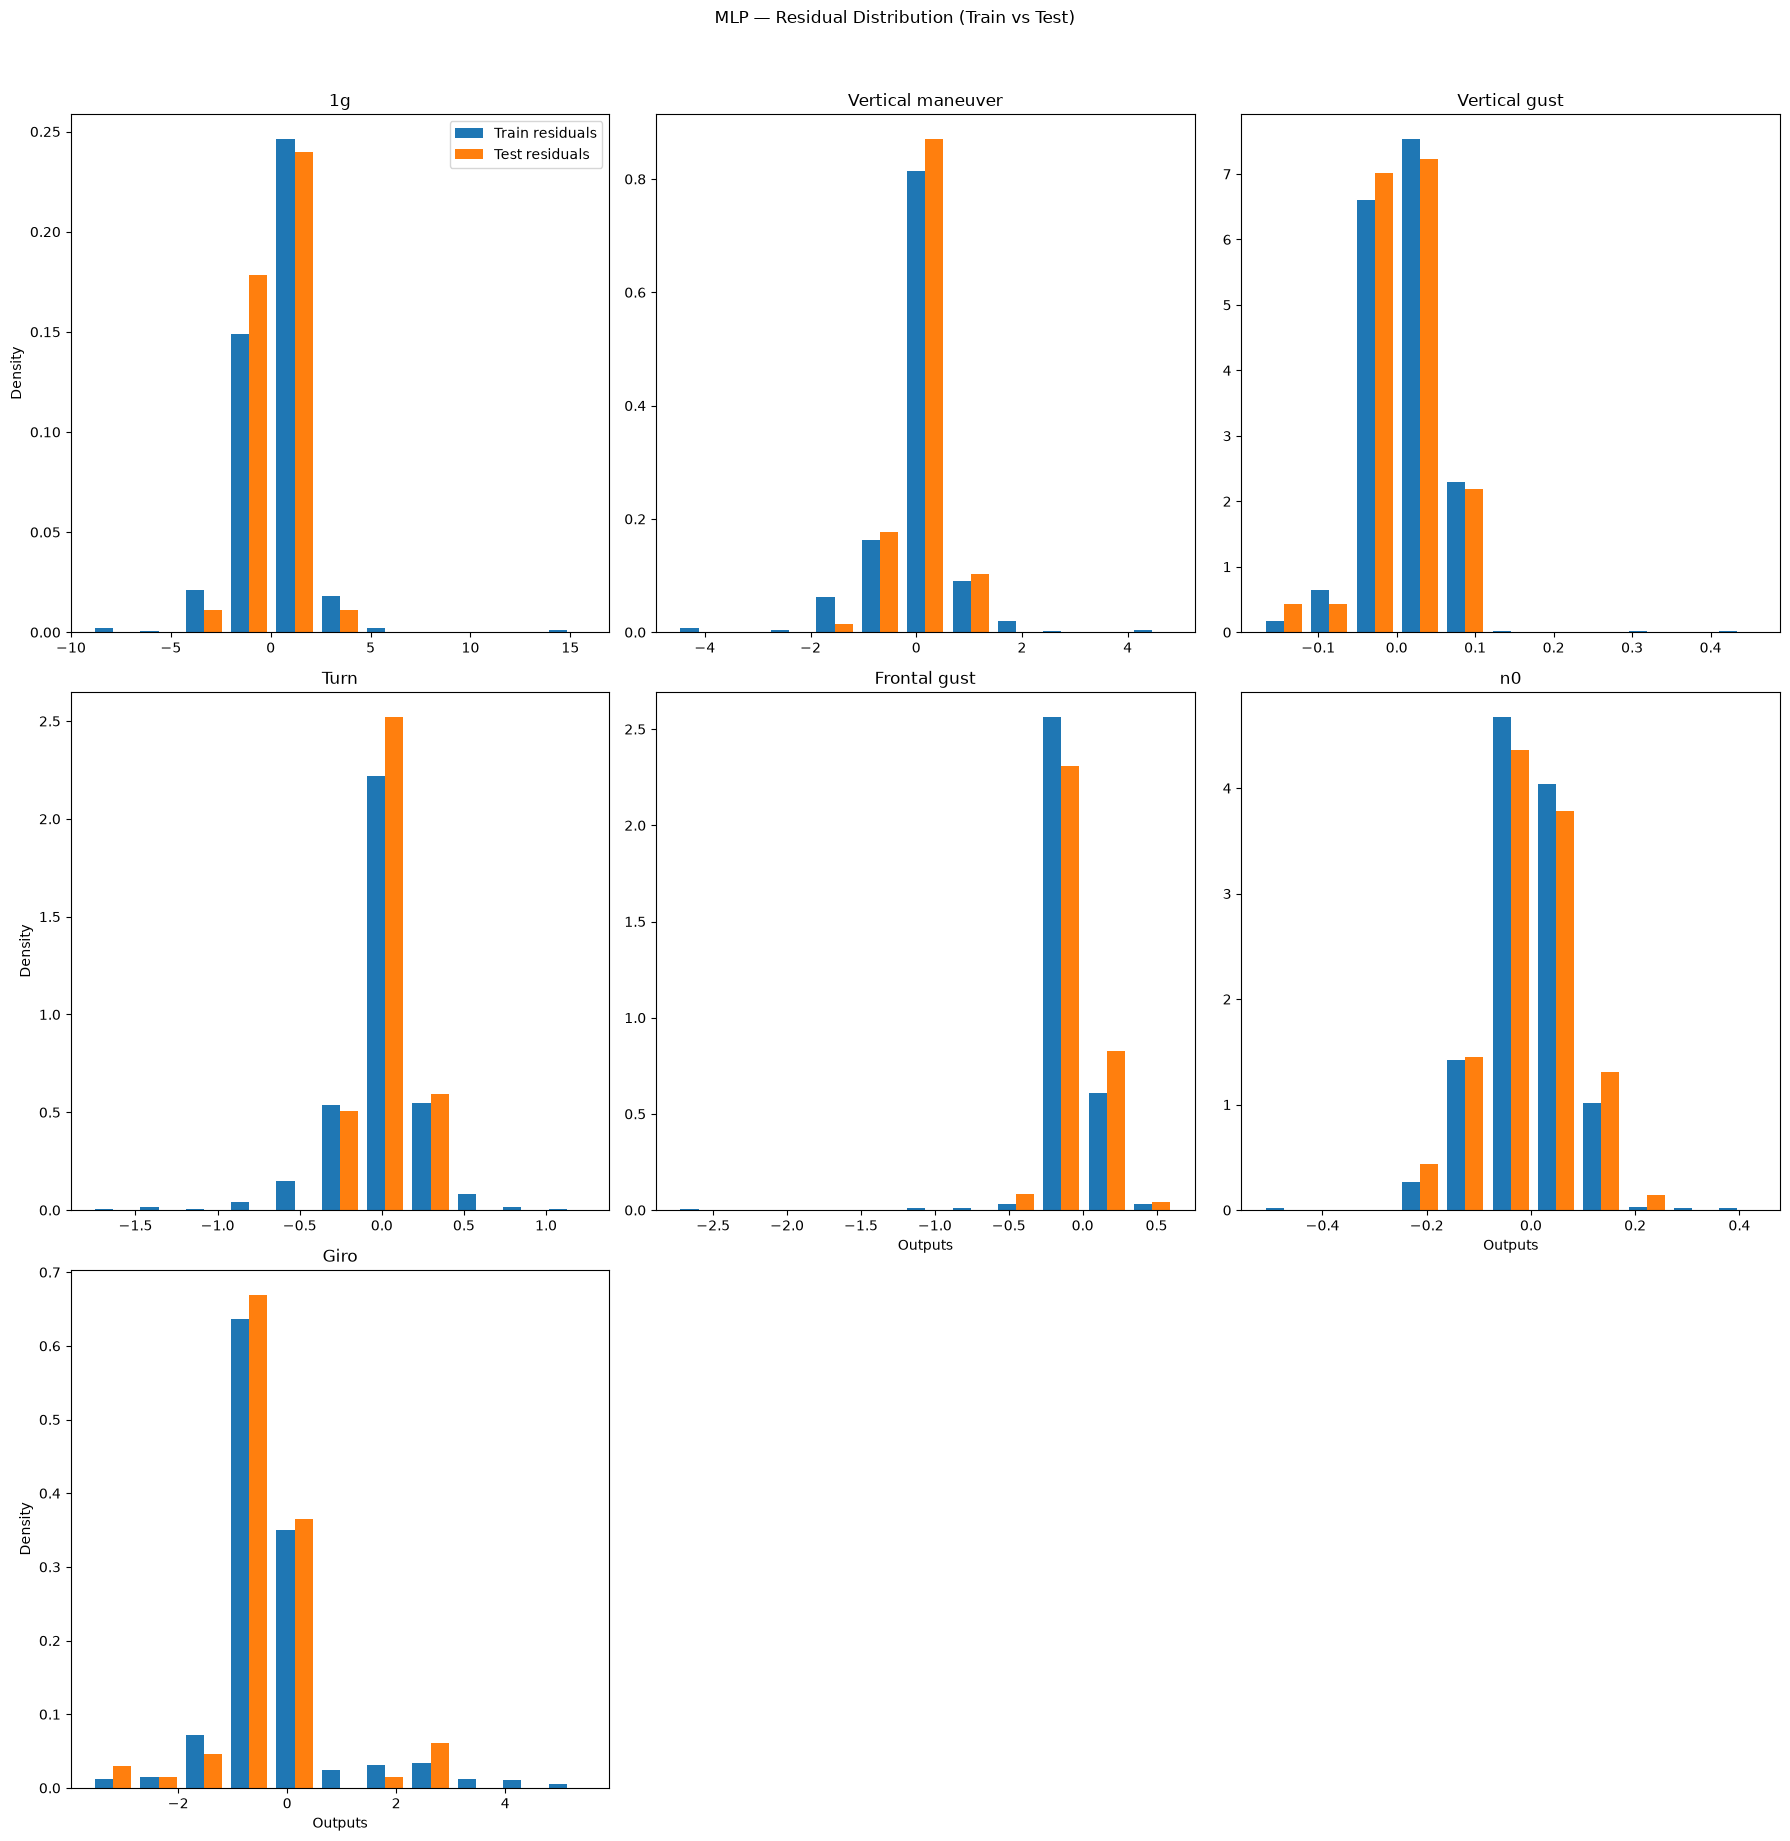

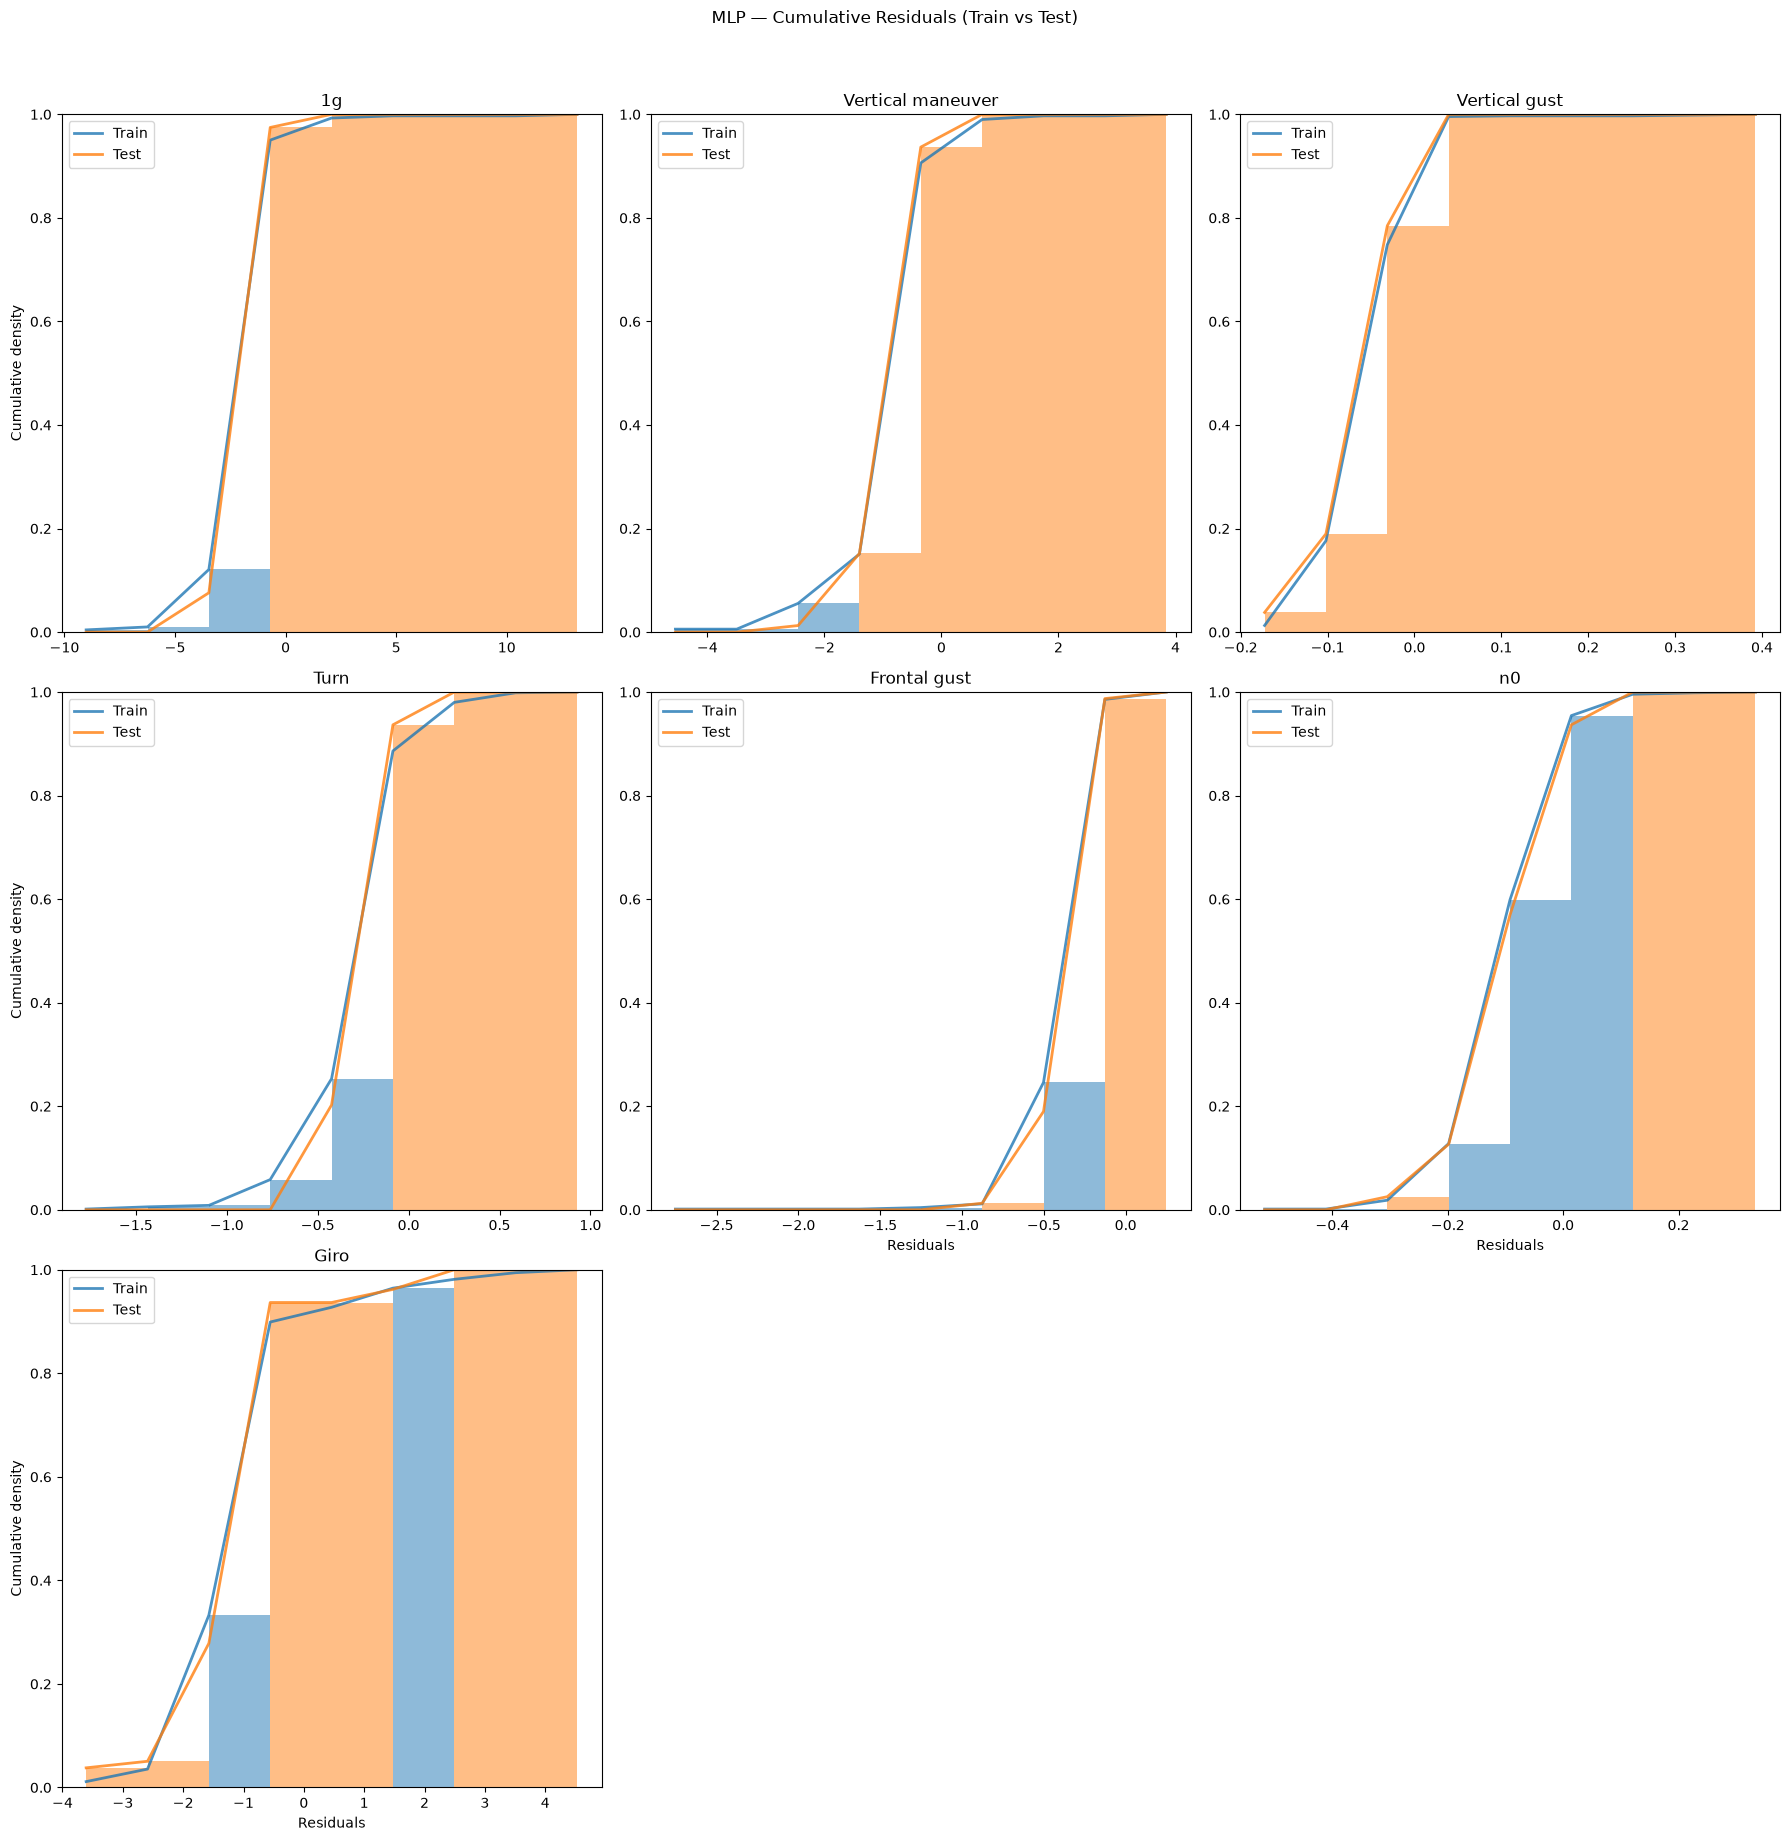

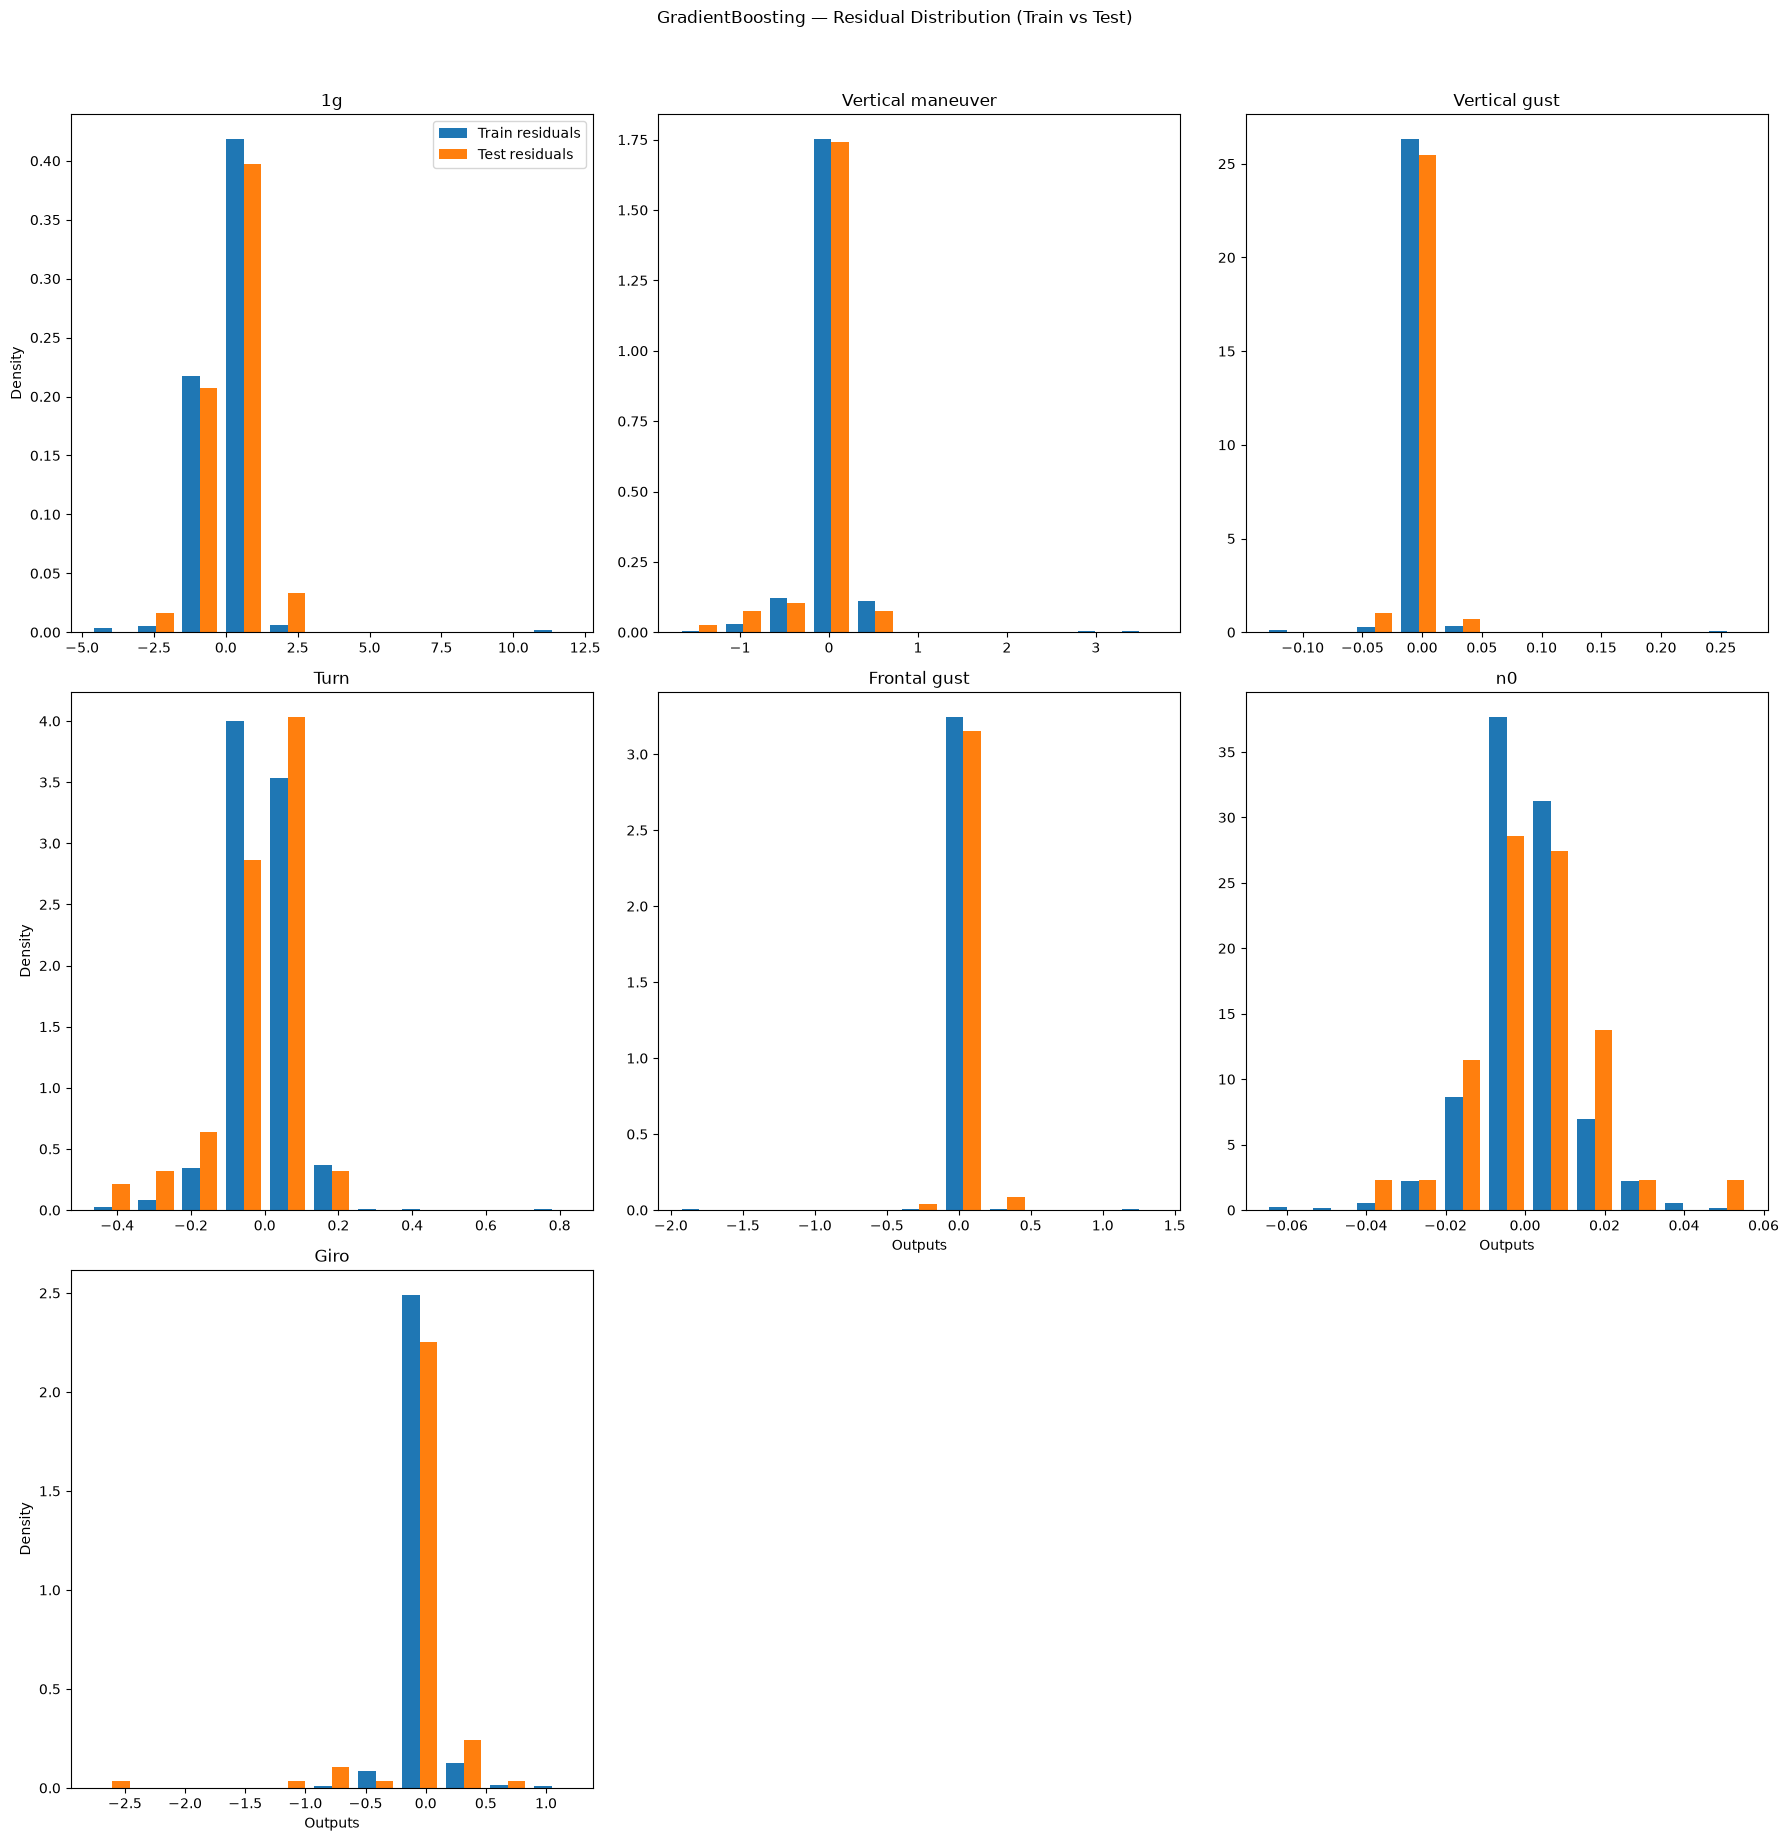

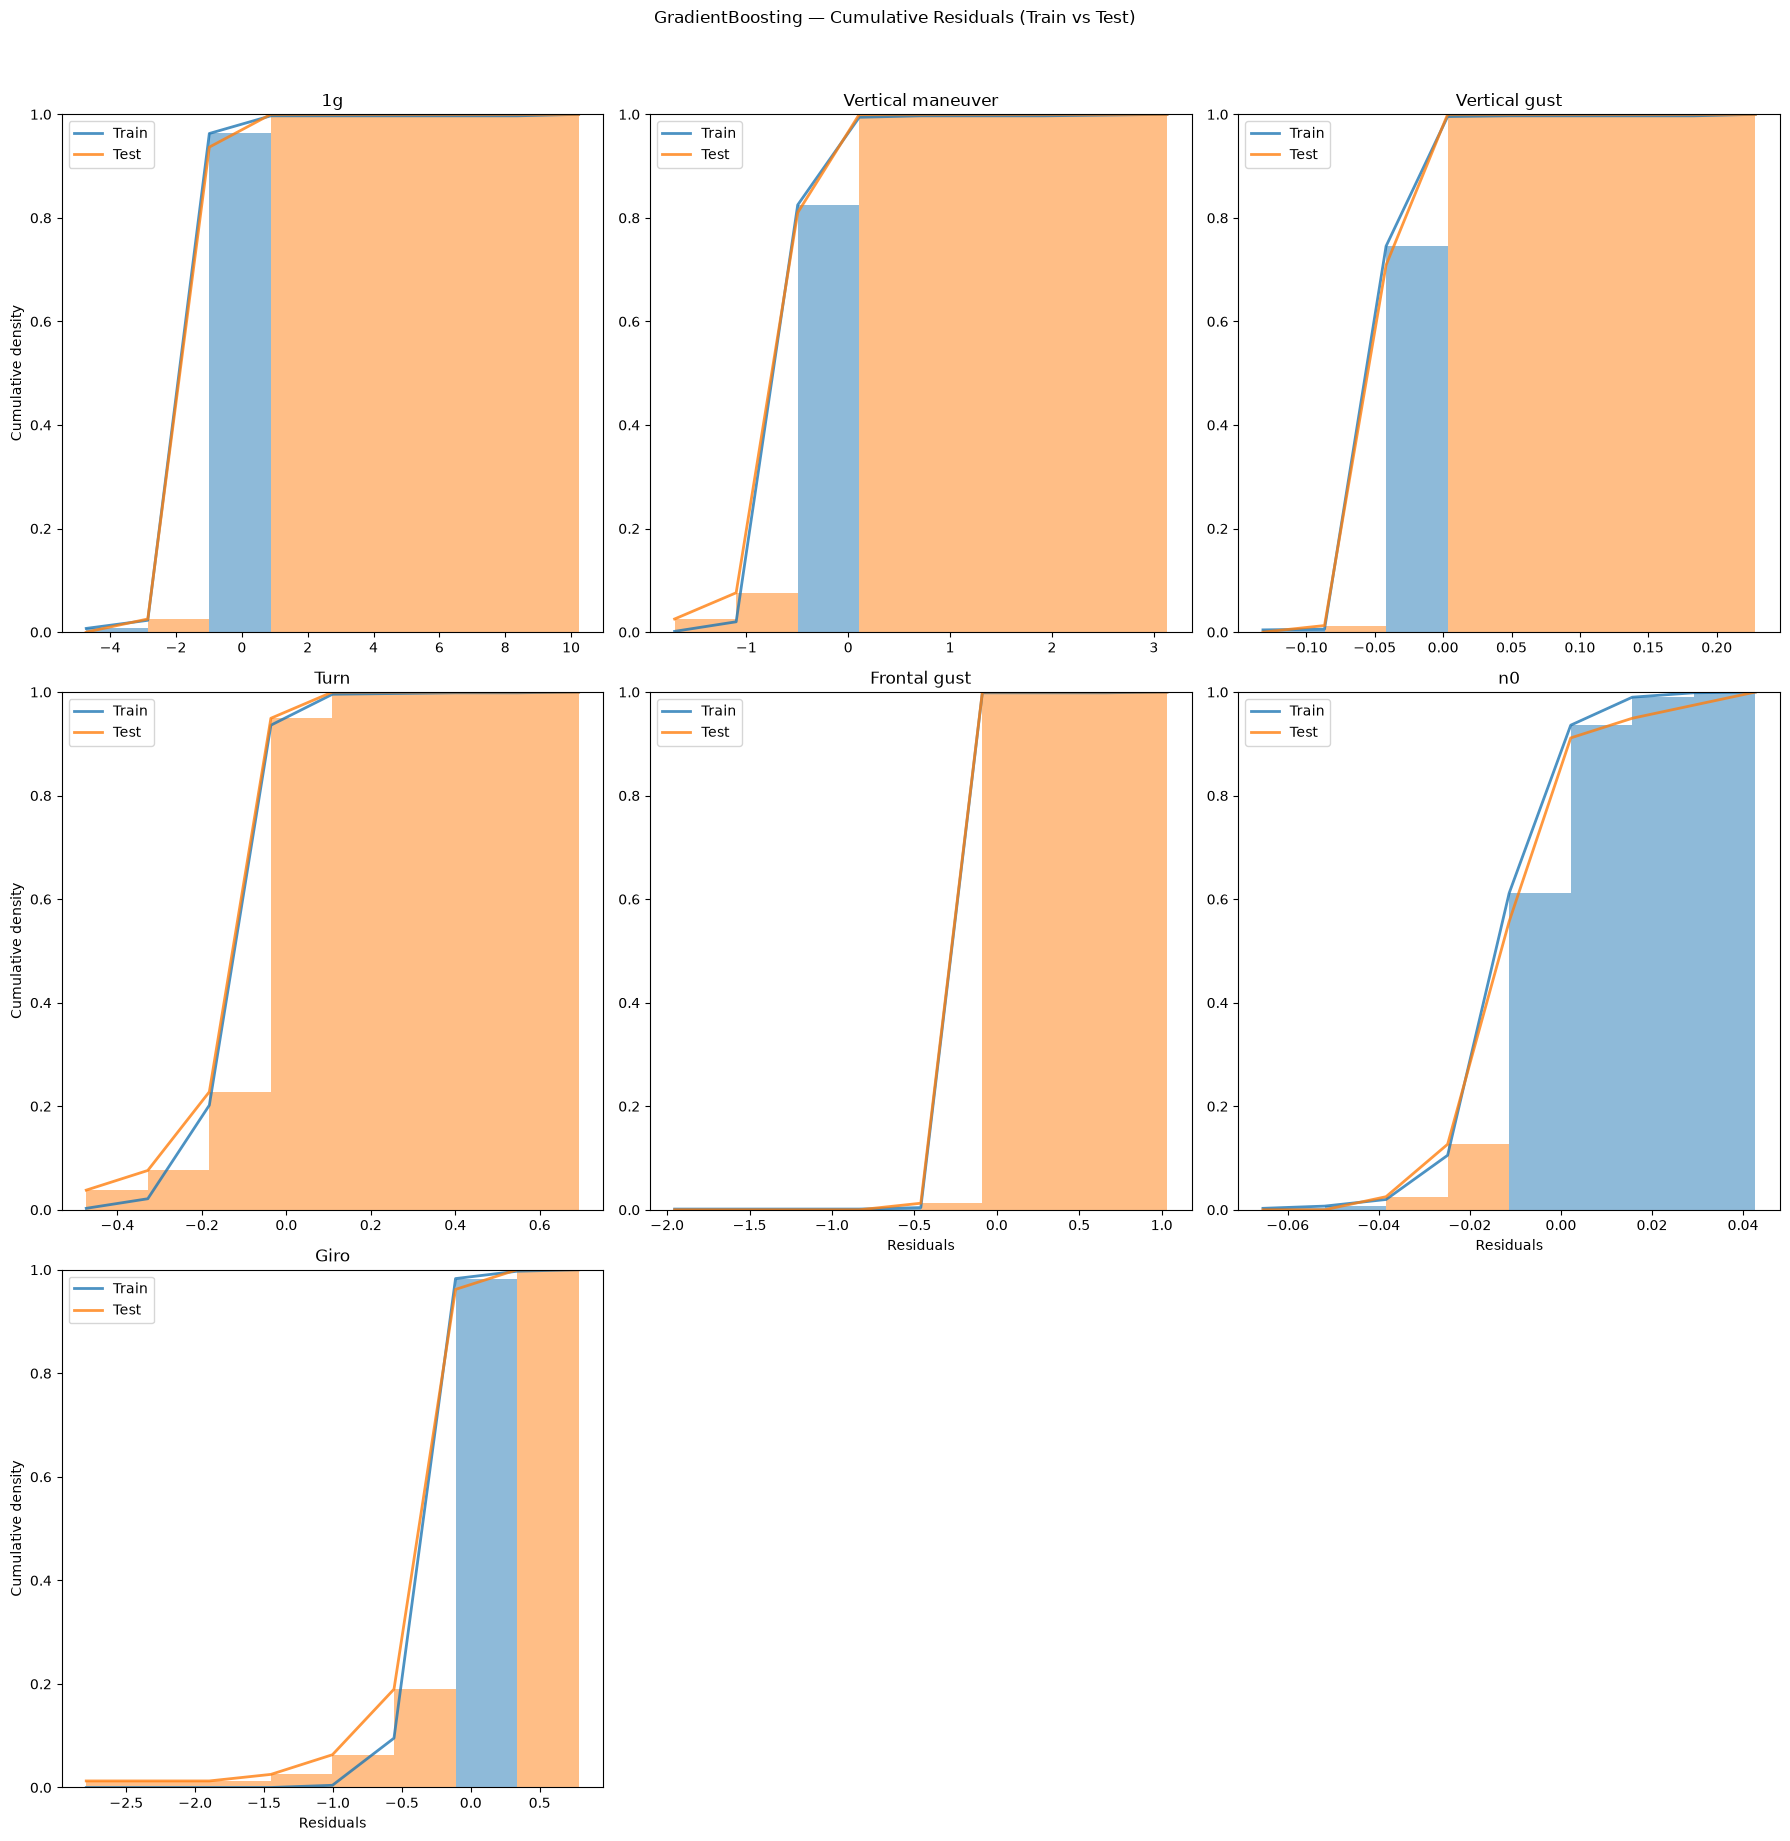

In [9]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from validationlib.plots.hist import doubleHistogram
from validationlib.plots.cumu import doublecumulative

ms = workflow.metadata.get_step_data(['metadata', 'Model_Selection'])
outputs = ms['outputs']
models_info = workflow.metadata.get_step_data(['metadata', 'Model_Training', 'Models'])

for info in models_info:
    label = info['label']

    train_res = pd.DataFrame(
        {col: Train_set[col].values - train_output[f'{label}__{col}'].values for col in outputs}
    )
    test_res = pd.DataFrame(
        {col: Test_set[col].values - model_output[f'{label}__{col}'].values for col in outputs}
    )

    # Histogram
    fig = doubleHistogram(
        train_res, test_res,
        x1label='Train residuals', x2label='Test residuals', xlabel='Outputs',
        multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
    )
    fig.suptitle(f'{label} — Residual Distribution (Train vs Test)', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Cumulative
    fig2 = doublecumulative(
        train_res, test_res,
        label1='Train', label2='Test', xlabel='Residuals',
        multiPlotsKwargs={'figHsize': 18, 'figAspectRatio': 3}
    )
    fig2.suptitle(f'{label} — Cumulative Residuals (Train vs Test)', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.close(fig2)

#### 9.3 Validation against requirements

In [10]:
from model_validation.validation import validate
validate(workflow, metrics)

2026-06-25 12:24:46 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'validate'



  Output                      Metric          Target                 MLPGradientBoosting
  ------------------------------------------------------------------------------------
  1g                          quantile90      0.1000      ✓     0.0324✓     0.0158
  Vertical maneuver           quantile90      0.1000      ✓     0.0442✓     0.0214
  Vertical gust               quantile90      0.1000      ✗     0.1239✓     0.0200
  Turn                        quantile90      0.1000      ✓     0.0424✓     0.0277
  Frontal gust                quantile90      0.1000      ✗    15.3827✓     0.0683
  n0                          quantile90      0.1000      ✓     0.0672✓     0.0109
  Giro                        quantile90      0.1000      ✗     0.9568✗     0.1492


#### 9.3b Validation Summary — Interactive Table
Pass/fail per model and output, colour-coded.

In [11]:
import ipywidgets as widgets
import pandas as pd
from IPython.display import display

validation_results = workflow.metadata.get_step_data(['metadata', 'Model_Validation', 'validation_results'])
models_info_w = workflow.metadata.get_step_data(['metadata', 'Model_Training', 'Models'])
labels_w = [m['label'] for m in models_info_w]

rows = []
for vr in validation_results:
    row = {'Output': vr['output'], 'Metric': vr['metric'], 'Target': f"< {vr['target']}"}
    for lbl in labels_w:
        m = vr['models'].get(lbl, {})
        score, passed = m.get('score'), m.get('passed')
        row[lbl] = (f"{'✅' if passed else '❌'} {score:.4f}") if score is not None else '?'
    rows.append(row)

df_val = pd.DataFrame(rows).set_index('Output')

def color_cell(val):
    if '✅' in str(val): return 'background-color:#d4edda; color:#155724'
    if '❌' in str(val): return 'background-color:#f8d7da; color:#721c24'
    return ''

styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')
display(styled)

/var/folders/p1/nzt7bhk56jn6tj9cf8sbh8ym0000gn/T/ipykernel_33281/3740910048.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')


,Metric,Target,MLP,GradientBoosting
Output,,,,
1g,quantile90,< 0.1,✅ 0.0324,✅ 0.0158
Vertical maneuver,quantile90,< 0.1,✅ 0.0442,✅ 0.0214
Vertical gust,quantile90,< 0.1,❌ 0.1239,✅ 0.0200
Turn,quantile90,< 0.1,✅ 0.0424,✅ 0.0277
Frontal gust,quantile90,< 0.1,❌ 15.3827,✅ 0.0683
n0,quantile90,< 0.1,✅ 0.0672,✅ 0.0109
Giro,quantile90,< 0.1,❌ 0.9568,❌ 0.1492


#### 9.4 Plots

2026-06-25 12:24:46 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'plot'


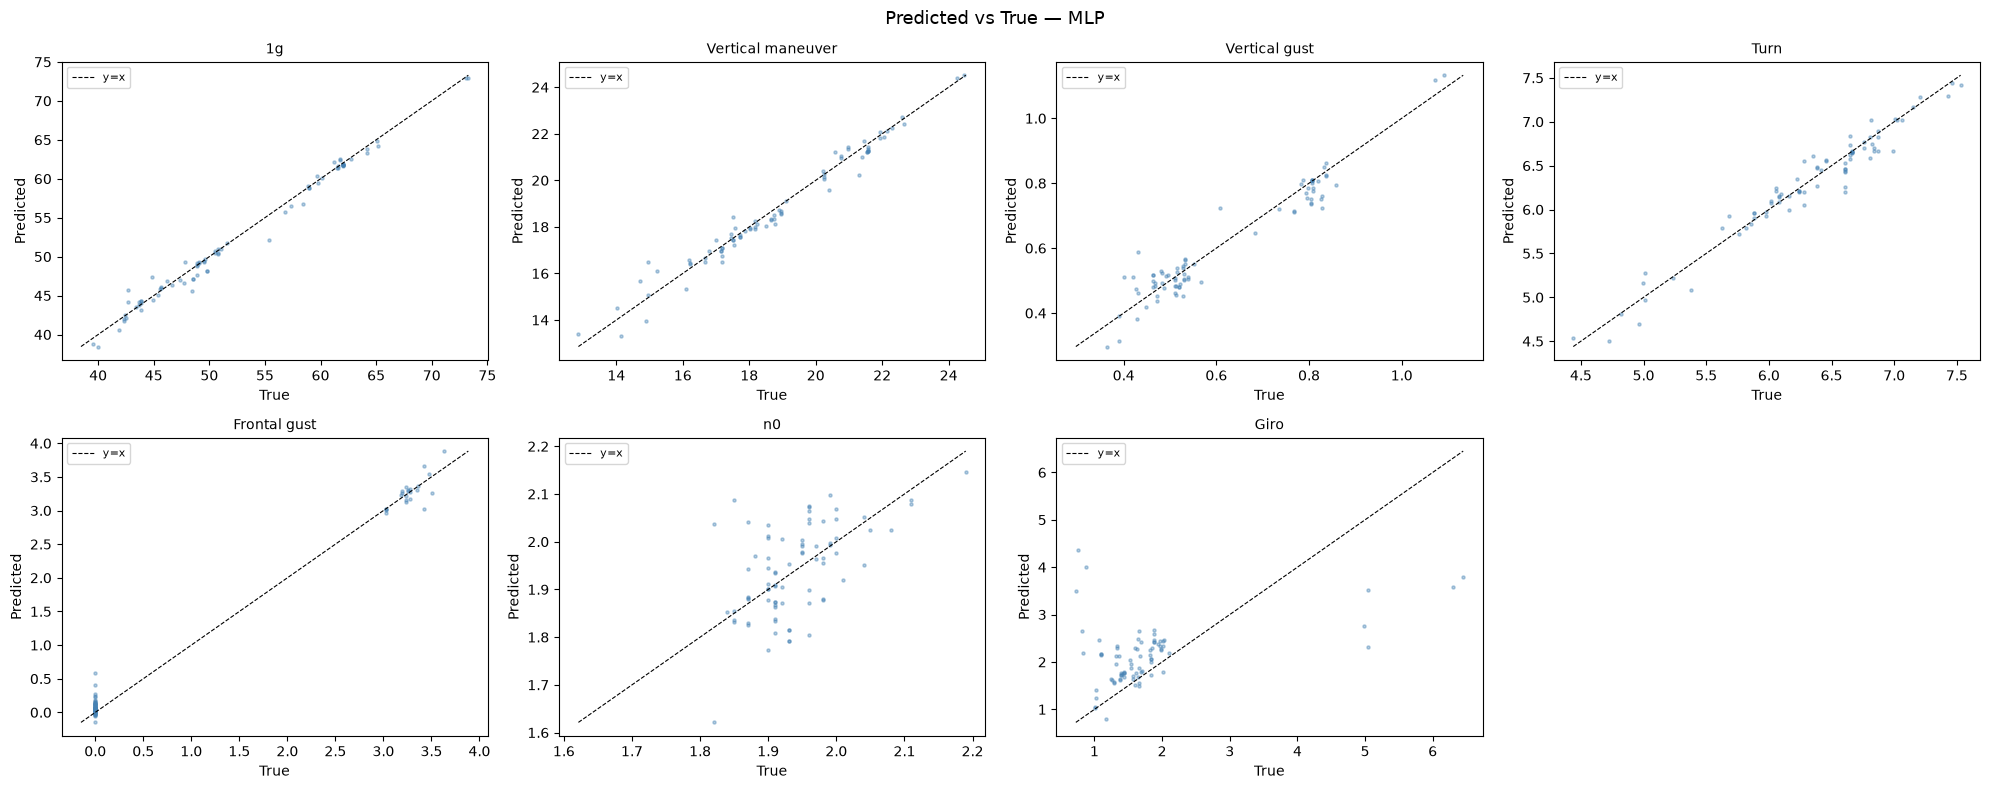

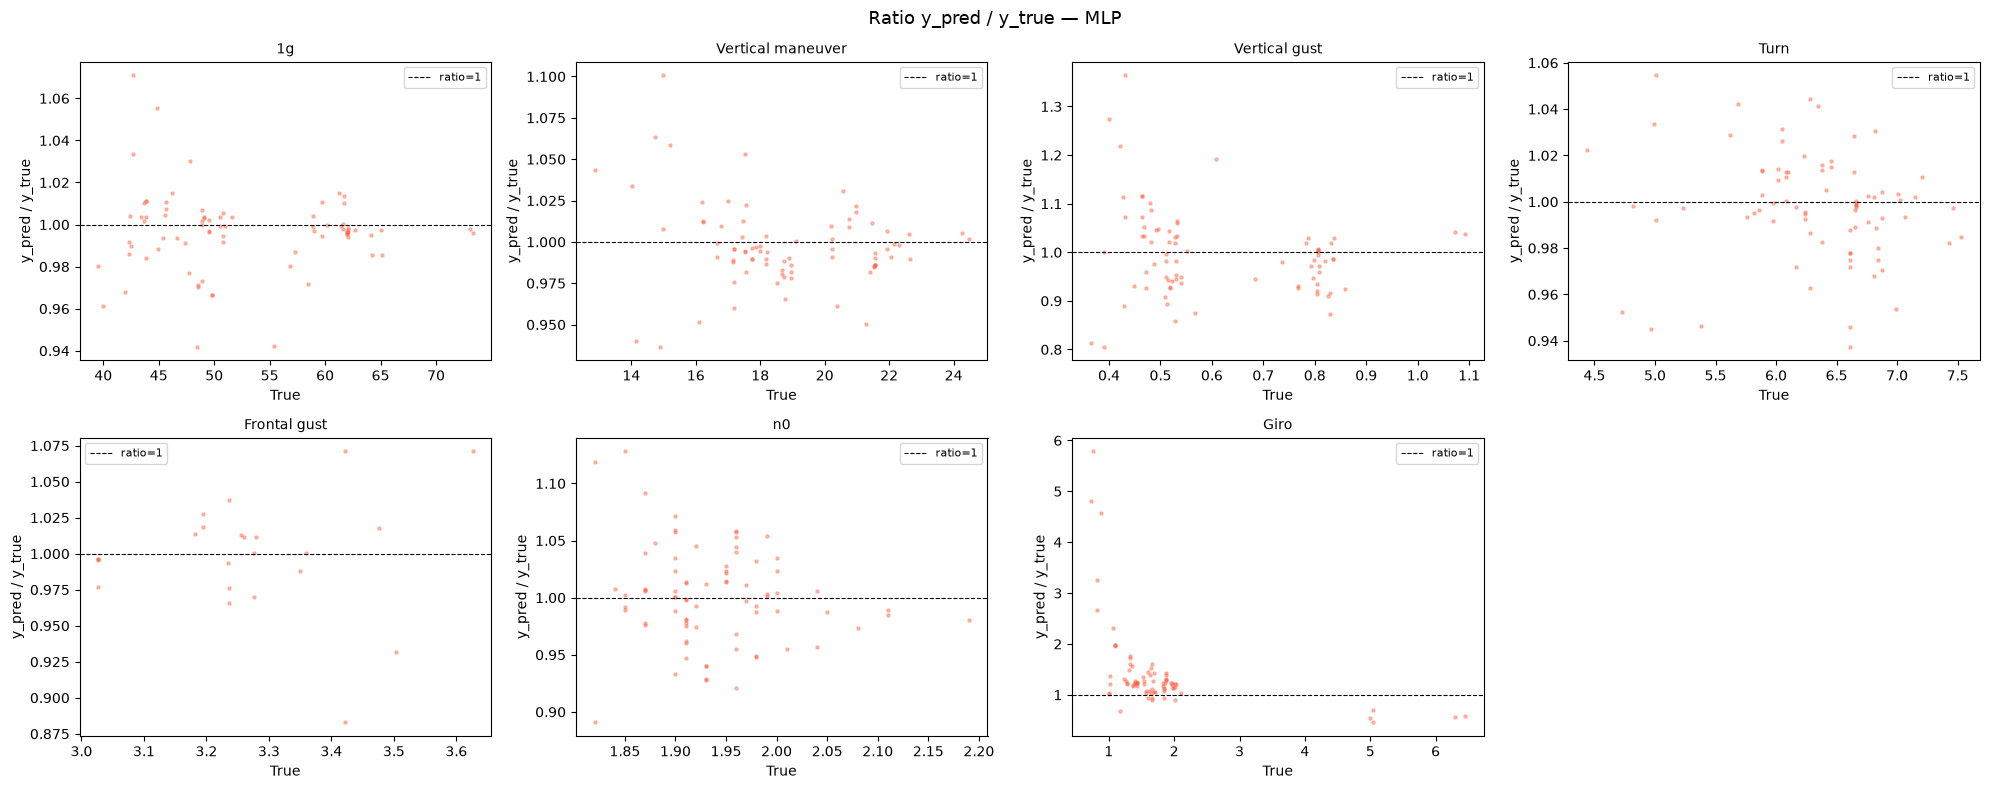

[MLP] scatter → scatter_MLP.png   ratio → ratio_MLP.png


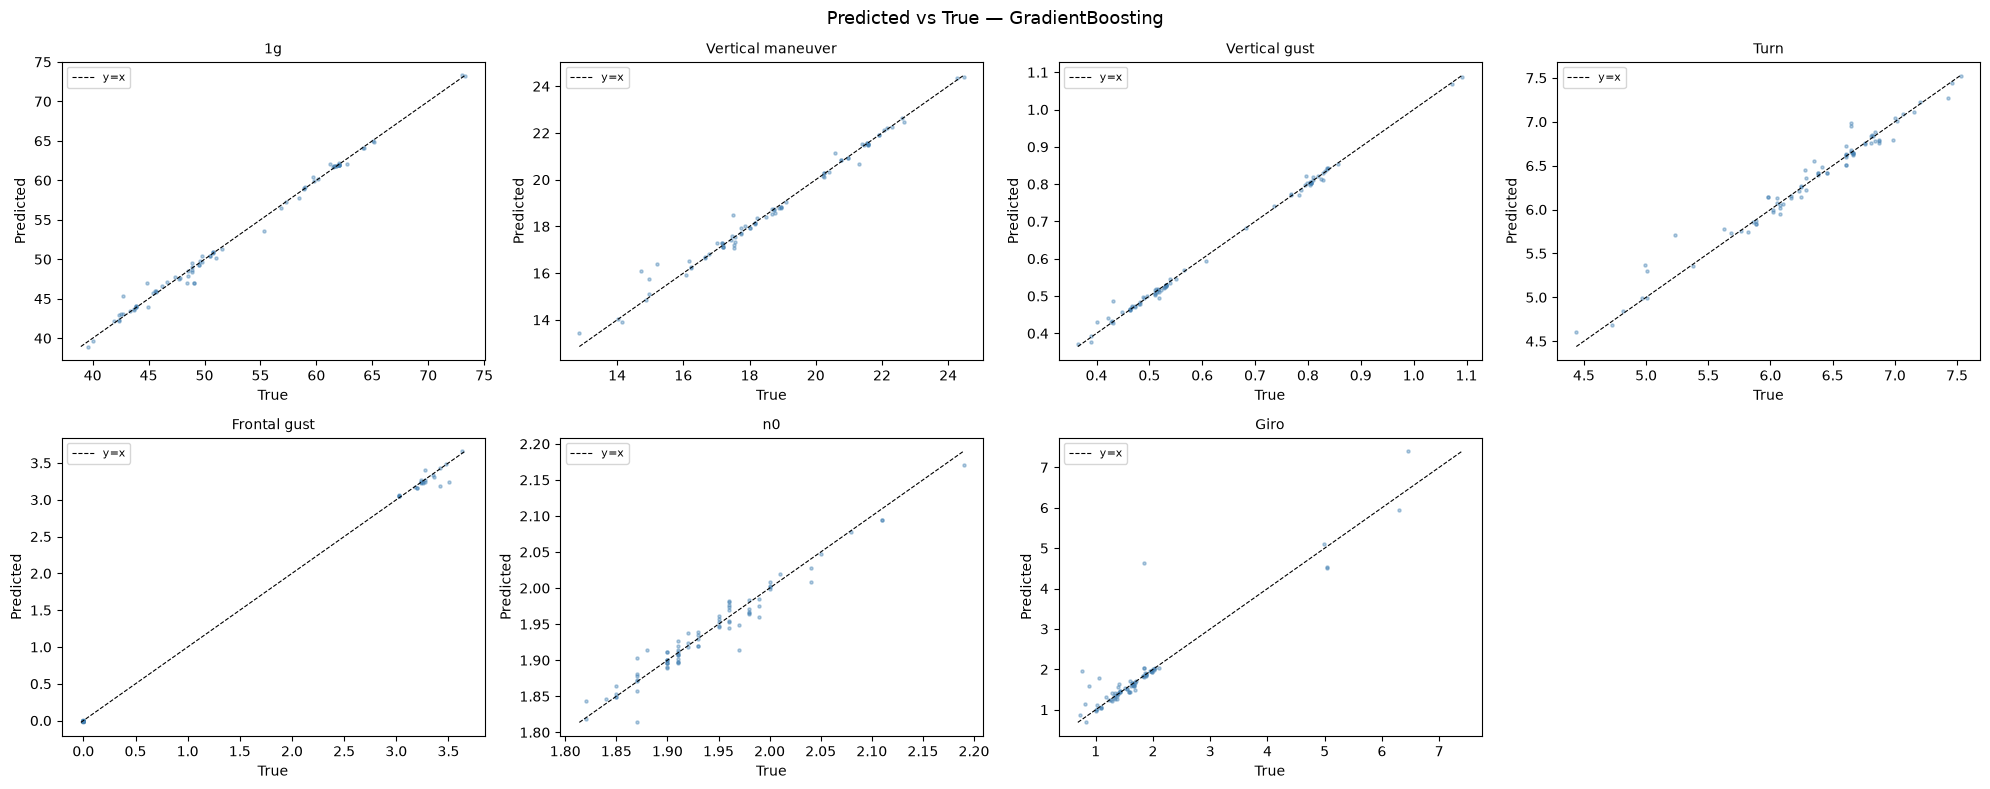

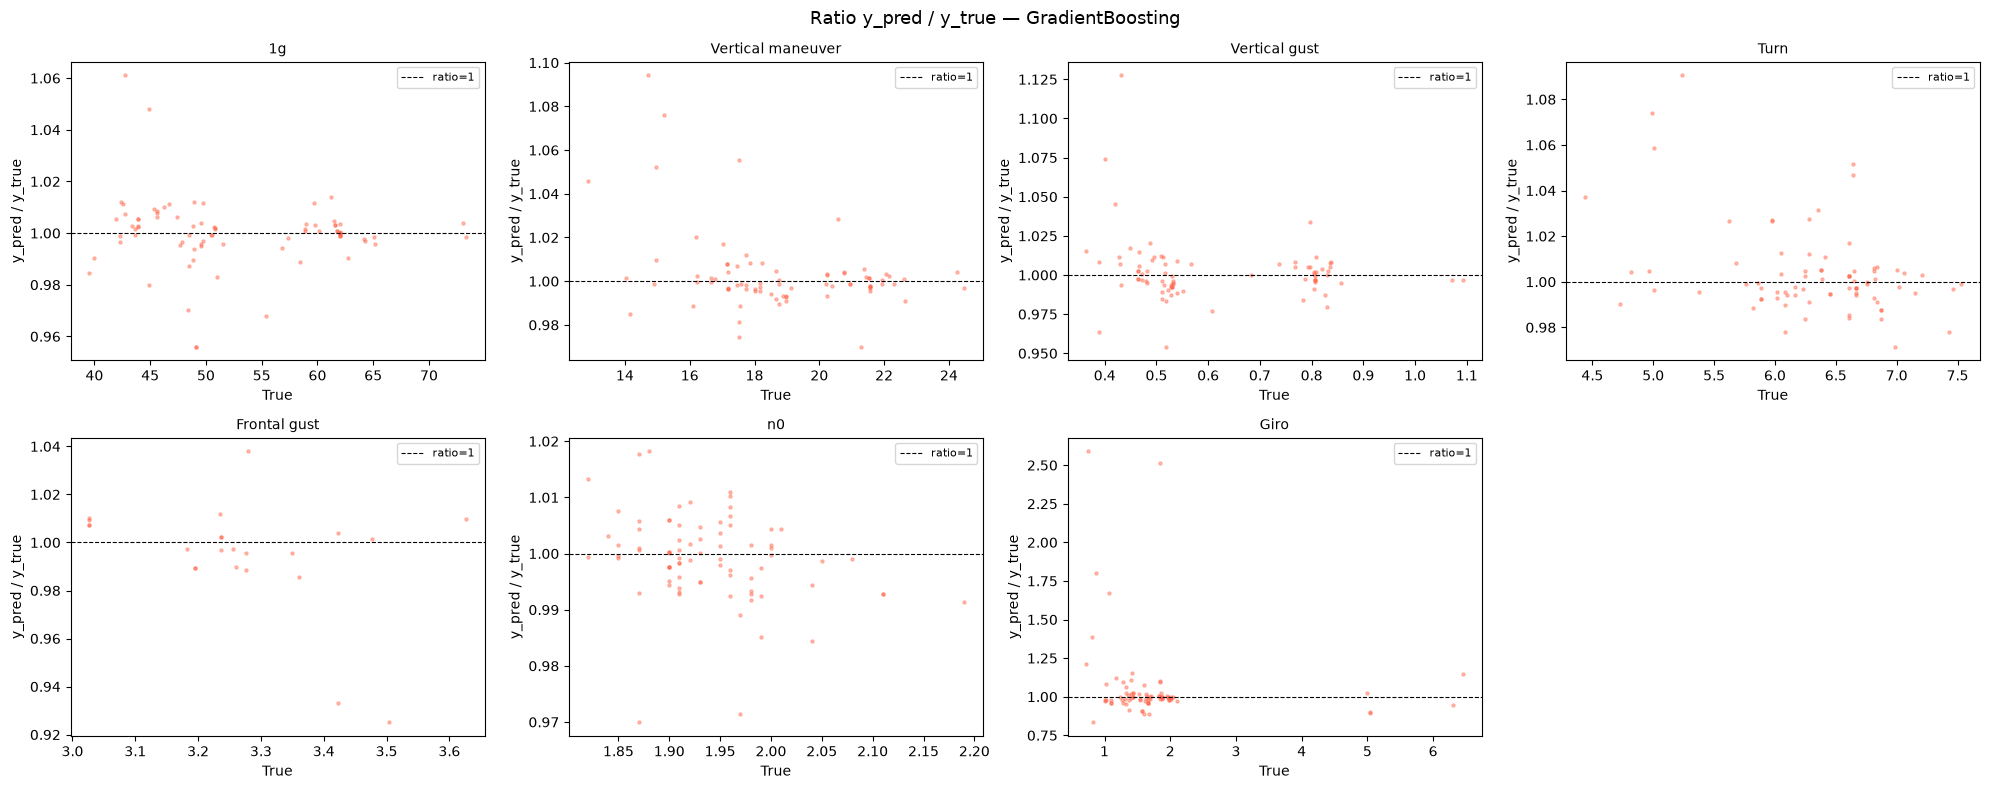

[GradientBoosting] scatter → scatter_GradientBoosting.png   ratio → ratio_GradientBoosting.png


In [12]:
%matplotlib inline
from model_validation.visualize import plot
plot(workflow, Test_set, model_output)

#### 9.4b Interactive Scatter Explorer
Select model and output to explore predictions.

In [13]:
%matplotlib inline
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display

ms_w      = workflow.metadata.get_step_data(["metadata", "Model_Selection"])
outputs_w = ms_w["outputs"]
mi_w      = workflow.metadata.get_step_data(["metadata", "Model_Training", "Models"])
labels_w  = [m["label"] for m in mi_w]

model_dd  = widgets.Dropdown(options=labels_w,  description="Model:",  layout=widgets.Layout(width="180px"))
output_dd = widgets.Dropdown(options=outputs_w, description="Output:", layout=widgets.Layout(width="220px"))
out_w     = widgets.Output()

def update_scatter(*_):
    label = model_dd.value
    col   = output_dd.value
    with out_w:
        out_w.clear_output(wait=True)
        y_true = Test_set[col].values
        y_pred = model_output[f"{label}__{col}"].values
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        axes[0].plot([lo, hi], [lo, hi], "k--", lw=0.8, label="y = x")
        axes[0].scatter(y_true, y_pred, s=8, alpha=0.45, color="steelblue")
        axes[0].set_xlabel("True"); axes[0].set_ylabel("Predicted")
        axes[0].set_title(f"{label} — {col}  (predicted vs true)")
        axes[0].legend(fontsize=8)
        mask  = y_true != 0
        ratio = y_pred[mask] / y_true[mask]
        axes[1].axhline(1.0, color="k", lw=0.8, linestyle="--", label="ratio = 1")
        axes[1].scatter(y_true[mask], ratio, s=8, alpha=0.45, color="tomato")
        axes[1].set_xlabel("True"); axes[1].set_ylabel("y_pred / y_true")
        axes[1].set_title(f"{label} — {col}  (ratio)")
        axes[1].legend(fontsize=8)
        plt.tight_layout()
        plt.show()

model_dd.observe(update_scatter, names="value")
output_dd.observe(update_scatter, names="value")
update_scatter()
display(widgets.HBox([model_dd, output_dd]), out_w)

Output()

#### 9.5 MLflow EDA Report
Logs a dedicated `EDA_Data_Report` run to MLflow with:
input/output distribution plots, correlation matrix, PCA coverage scatter,
split quality (VTP), KS p-values, R²/Q90/MAE per model, and summary CSVs.
Open the MLflow UI (`./start_jupyter.sh --mlflow`) to explore artefacts.

In [14]:
from tracking.mlflow_eda import log_eda

log_eda(
    workflow    = workflow,
    Train_set   = Train_set,
    Val_set     = Val_set,
    Test_set    = Test_set,
    model_output  = model_output,
    train_output  = train_output,
    metrics       = metrics,
    split_result  = split_result,
    ks_results    = ks_results,
)

[EDA] Run logged: c4f140b66a8c442aa0a32102f5693365


### Save

In [15]:
workflow.save_metadata()

2026-06-25 12:24:49 - SurrogateFactoryLogs - INFO - Successfully saved workflow metadata to: /Users/martaarnabatmartin/Desktop/Pipelines/UCFatigue/pipeline/data/artifacts/metadata_UCFATIGUE_1.json
